In [ ]:
# Set up the environment by installing the required packages
!pip install -r requirements.txt

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import xgboost as xgb

# Model evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Visualisations
import matplotlib.pyplot as plt


In [2]:
#Loading the data into train and test sets
train = pd.read_csv("../data/processed/final_train_scaled_encoded.csv")
test = pd.read_csv("../data/processed/final_test_scaled_encoded.csv")

#Making the input and output train and test sets
X_train = train.drop("Risk", axis=1)
y_train = train["Risk"]

X_test = test.drop("Risk", axis=1)
y_test = test["Risk"]

In [3]:
#Applying SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [4]:
# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))
print("Test Accuracy:", accuracy_score(y_test, rf_preds))

print("\n")

# XGBoost
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
xgb_clf.fit(X_train_bal, y_train_bal)
xgb_preds = xgb_clf.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print(confusion_matrix(y_test, xgb_preds))
print("Test Accuracy:", accuracy_score(y_test, xgb_preds))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.54      0.60      0.57        60
           1       0.82      0.78      0.80       140

    accuracy                           0.72       200
   macro avg       0.68      0.69      0.68       200
weighted avg       0.73      0.72      0.73       200

[[ 36  24]
 [ 31 109]]
Test Accuracy: 0.725


XGBoost Results:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        60
           1       0.81      0.81      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200

[[ 33  27]
 [ 27 113]]
Test Accuracy: 0.73


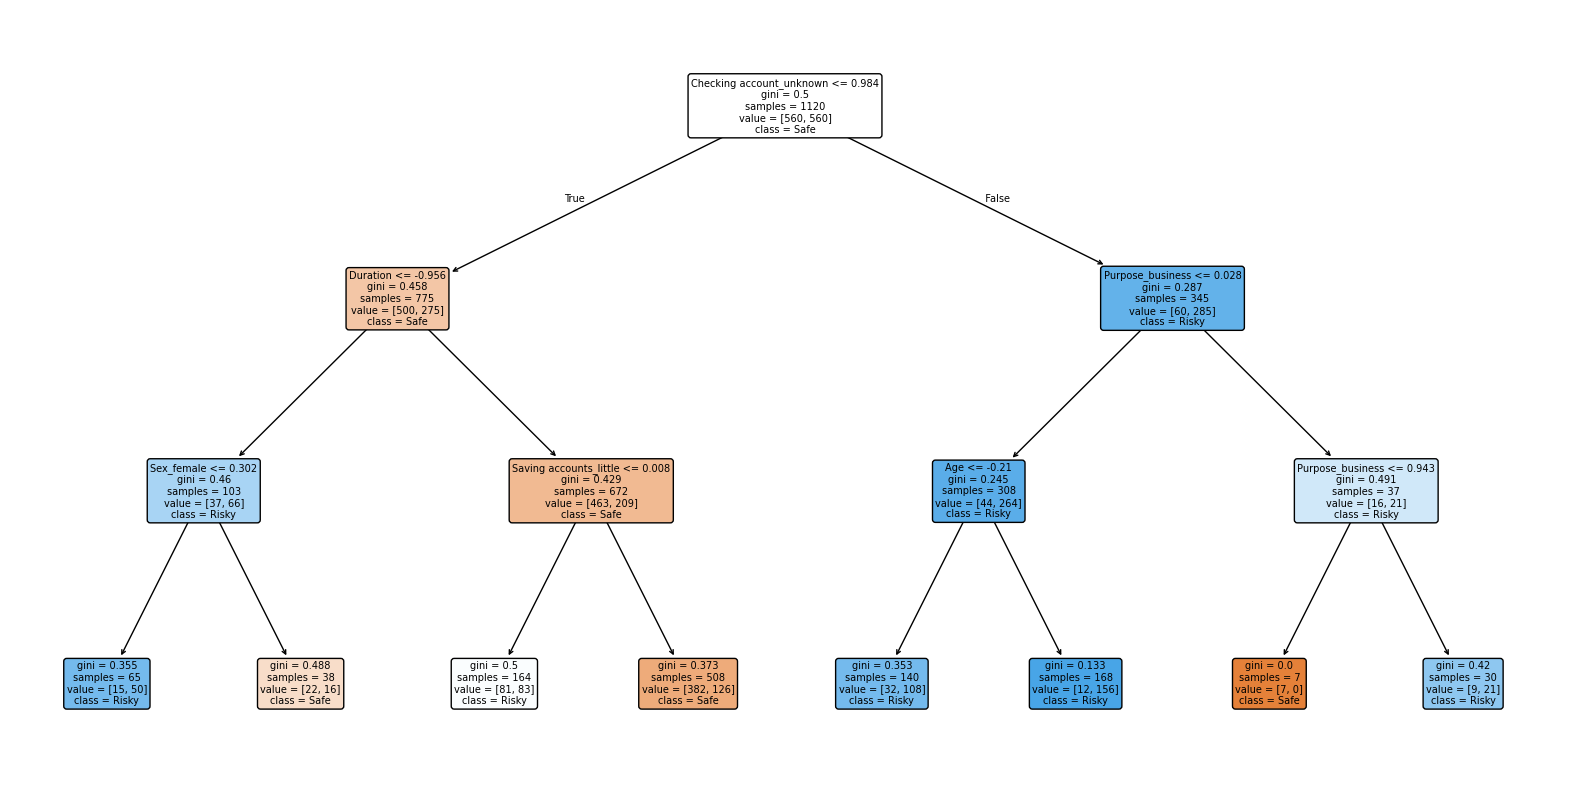

In [5]:
# Decision Tree for visualization
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_bal, y_train_bal)

# Plotting the tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train.columns, class_names=["Safe","Risky"], label='all', rounded=True, filled=True)
plt.show()

In [7]:
# Hyperparameter tuning for Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",   # focus on recall for risky loans
    n_jobs=-1
)

grid_rf.fit(X_train_bal, y_train_bal)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF Recall:", grid_rf.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best RF Recall: 0.8125
